# Prática 1 Avaliação de classificação com K-NN

Centro Universitário IESB · Análise e Desenvolvimento de Sistemas

Aprendizagem de Máquina · Aula 6

Objetivo: explicar o efeito da escala, escolher o número de vizinhos por validação e interpretar os erros de classificação.
Tempo de prática guiada: cerca de 40 minutos, após a discussão dos conceitos na aula.
Em dupla: antes de executar uma célula, antecipe o resultado; depois compare a previsão com a saída.
A base de células mamárias é usada apenas como exemplo didático de classificação.


## Antes de começar
Abra este arquivo no Jupyter, no VS Code com suporte a notebooks ou no Google Colab.
Execute as células na ordem. Os dados são locais ao scikit-learn ou gerados pelo próprio notebook;
nenhum download de dataset é necessário. O Colab precisa de conexão para funcionar.

Dependências: NumPy, pandas, Matplotlib e scikit-learn 1.4 ou posterior.
Se faltar uma biblioteca, execute em uma nova célula `%pip install numpy pandas matplotlib "scikit-learn>=1.4"`
e reinicie o kernel. Não é necessário instalar novamente quando os imports já funcionam.
As versões usadas na conferência estão no arquivo LEIA_ME.md.


In [12]:
pip install --upgrade scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [14]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, GridSearchCV, cross_validate, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report,
                             mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score)
plt.rcParams.update({'figure.figsize': (8, 4), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
SEMENTE = 42
print('Python:', sys.version.split()[0], '| scikit-learn:', sklearn.__version__)


ImportError: cannot import name 'root_mean_squared_error' from 'sklearn.metrics' (c:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\__init__.py)

## 1 Uma distância pode depender da unidade
Considere três clientes fictícios. A mensalidade é medida em reais e a quantidade de chamados é uma contagem.
Antes de executar: qual atributo dominará a distância euclidiana sem escala?
O novo cliente é uma observação ainda sem rótulo. A escala é aprendida exclusivamente nos três clientes de referência.


In [ ]:
clientes = pd.DataFrame({'mensalidade_reais': [50., 100., 150.], 'chamados': [0., 2., 4.]}, index=['A', 'B', 'C'])
novo = pd.DataFrame({'mensalidade_reais': [110.], 'chamados': [4.]})
escala_exemplo = MinMaxScaler().fit(clientes)
dist_sem = np.sqrt(((clientes.to_numpy() - novo.to_numpy()) ** 2).sum(axis=1))
dist_com = np.sqrt(((escala_exemplo.transform(clientes) - escala_exemplo.transform(novo)) ** 2).sum(axis=1))
exemplo_escala = clientes.assign(distancia_sem_escala=dist_sem, distancia_minmax=dist_com)
display(exemplo_escala.round(4))
print('Vizinho mais próximo sem escala:', clientes.index[np.argmin(dist_sem)])
print('Vizinho mais próximo com Min-Max:', clientes.index[np.argmin(dist_com)])


,mensalidade_reais,chamados,distancia_sem_escala,distancia_minmax
A,50.0,0.0,60.1332,1.1662
B,100.0,2.0,10.1980,0.5099
C,150.0,4.0,40.0000,0.4000


Vizinho mais próximo sem escala: B
Vizinho mais próximo com Min-Max: C


**Pergunta 1.** A escala muda o significado do alvo ou muda a comparação entre os atributos? Explique por que a unidade monetária não deve, sozinha, definir a proximidade.

Resposta da dupla: ...

## 2 Dados e teste reservado
Uma linha representa uma amostra; as 30 colunas descrevem medidas numéricas. Usaremos o mesmo tipo de base do laboratório do Coursera.
`X` contém os atributos e `y` contém o rótulo. A classe positiva precisa estar explícita.
Separar 20% é uma escolha didática, não uma proporção obrigatória para qualquer problema.


In [ ]:
from sklearn.datasets import load_breast_cancer
dados = load_breast_cancer(as_frame=True)
X = dados.data
# No original: 0 = maligno e 1 = benigno. Aqui, definimos explicitamente a classe positiva.
y = (dados.target == 0).astype(int).rename('maligno')
X_dev, X_teste, y_dev, y_teste = train_test_split(
    X, y, test_size=0.20, random_state=SEMENTE, stratify=y)
print('Desenvolvimento:', X_dev.shape, '| Teste reservado:', X_teste.shape)
print('Classe 0 = benigno; classe 1 = maligno (positiva).')
display(y_dev.value_counts().sort_index().rename('quantidade'))
display(X_dev.iloc[:, :4].head())


NameError: name 'SEMENTE' is not defined

## 3 Treino e validação com transformação manual
Nesta demonstração: cerca de 60% para treino, 20% para validação e 20% para teste.
`fit_transform` aprende a média e o desvio do treino e transforma esse conjunto.
`transform` usa esses mesmos valores na validação. Não calculamos novas médias para validá-lo.


In [ ]:
# 25% dos 80% de desenvolvimento correspondem a aproximadamente 20% do total.
X_treino, X_valid, y_treino, y_valid = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=SEMENTE, stratify=y_dev)

scaler_manual = StandardScaler()
X_treino_pad = scaler_manual.fit_transform(X_treino)
X_valid_pad = scaler_manual.transform(X_valid)  # apenas aplica a regra do treino
knn_manual = KNeighborsClassifier(n_neighbors=5)
knn_manual.fit(X_treino_pad, y_treino)
pred_valid_manual = knn_manual.predict(X_valid_pad)
print('F1 na validação:', round(f1_score(y_valid, pred_valid_manual), 4))


NameError: name 'X_dev' is not defined

## 4 A mesma sequência em um Pipeline
Um `Pipeline` encadeia etapas. `fit` aprende a transformação e ajusta o K-NN; `predict` transforma a nova entrada e faz a previsão.
Nos próximos experimentos, ele será refeito em cada divisão da validação. Isso evita que um fold de validação participe do ajuste da escala.


In [ ]:
modelo_pipe = Pipeline([('escala', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))])
modelo_pipe.fit(X_treino, y_treino)
pred_valid_pipe = modelo_pipe.predict(X_valid)
print('Mesmas previsões do procedimento manual?', np.array_equal(pred_valid_manual, pred_valid_pipe))

comparacao_escalas = []
for nome, transformador in [('Sem escala', 'passthrough'), ('StandardScaler', StandardScaler()), ('MinMaxScaler', MinMaxScaler())]:
    modelo = Pipeline([('escala', transformador), ('knn', KNeighborsClassifier(n_neighbors=5))])
    modelo.fit(X_treino, y_treino)
    comparacao_escalas.append({'escala': nome, 'k': 5, 'F1_validacao': f1_score(y_valid, modelo.predict(X_valid))})
display(pd.DataFrame(comparacao_escalas).round(4))


Mesmas previsões do procedimento manual? True


,escala,k,F1_validacao
0,Sem escala,5,0.9048
1,StandardScaler,5,0.9639
2,MinMaxScaler,5,0.9639


**Pergunta 2.** Mantendo `k=5`, qual transformação obteve o maior F1 nesta divisão? Por que esse resultado não prova que ela será sempre superior?

Resposta da dupla: ...

## 5 Escolha por validação cruzada
O K-NN possui um hiperparâmetro: o número de vizinhos. Ele é definido antes do ajuste.
Usaremos **F1 da classe 1** como critério didático principal, considerando precisão e recall conjuntamente. Não se trata de um critério de aprovação clínica.
`StratifiedKFold` cria cinco rodadas preservando aproximadamente a proporção de classes.
Em cada rodada, quatro partes treinam e uma valida. Os cinco folds são uma coisa; os vizinhos do K-NN são outra.

`GridSearchCV` experimenta a tabela de opções fornecida. `knn__n_neighbors` significa o parâmetro `n_neighbors` da etapa chamada `knn`.
`mean_test_score`, na saída desta busca, é a média nos **folds de validação**. Não corresponde ao nosso teste final reservado.
`refit=True` reajusta a melhor configuração usando todo `X_dev`. A busca não recebe `X_teste`.


In [ ]:
# A partir daqui, a validação cruzada usa os 80% de desenvolvimento.
# A divisão interna anterior foi uma demonstração. O teste permanece separado.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMENTE)
ks = [1, 3, 5, 7, 11, 15, 21, 31, 51, 101, 201]
pipeline = Pipeline([('escala', StandardScaler()),
                     ('knn', KNeighborsClassifier(weights='uniform', p=2))])
busca = GridSearchCV(
    pipeline,
    {'escala': ['passthrough', StandardScaler(), MinMaxScaler()],
     'knn__n_neighbors': ks},
    scoring='f1', cv=cv, refit=True, return_train_score=True,
    n_jobs=1, error_score='raise')
busca.fit(X_dev, y_dev)

def nome_escala(obj):
    return 'Sem escala' if isinstance(obj, str) else type(obj).__name__

resultados = pd.DataFrame(busca.cv_results_)
tabela_cv = pd.DataFrame({
    'escala': [nome_escala(p['escala']) for p in resultados['params']],
    'k': [p['knn__n_neighbors'] for p in resultados['params']],
    'F1_treino': resultados['mean_train_score'],
    'F1_validacao': resultados['mean_test_score'],
    'desvio_folds': resultados['std_test_score']})
display(tabela_cv.sort_values('F1_validacao', ascending=False).head(10).round(4))
print('Escolha pela validação:', busca.best_params_)
print('F1 médio de validação:', round(busca.best_score_, 4))


Escolha pela validação: {'escala': MinMaxScaler(), 'knn__n_neighbors': 3}
F1 médio de validação: 0.9663


,escala,k,F1_treino,F1_validacao,desvio_folds
23,MinMaxScaler,3,0.9767,0.9663,0.0265
12,StandardScaler,3,0.9760,0.9633,0.0250
24,MinMaxScaler,5,0.9700,0.9604,0.0313
14,StandardScaler,7,0.9597,0.9575,0.0116
25,MinMaxScaler,7,0.9645,0.9570,0.0231
13,StandardScaler,5,0.9660,0.9510,0.0263
26,MinMaxScaler,11,0.9589,0.9502,0.0304
27,MinMaxScaler,15,0.9510,0.9467,0.0344
15,StandardScaler,11,0.9518,0.9443,0.0219
16,StandardScaler,15,0.9493,0.9441,0.0267


## 6 Curva de validação
Variaremos o número de vizinhos mantendo `StandardScaler` para enxergar uma mudança por vez.
F1 maior é melhor. A faixa representa um desvio padrão entre folds, não um intervalo de confiança.
`k` pequeno tende a tornar o K-NN mais flexível; `k` muito grande pode suavizar demais.
As curvas observadas não precisam seguir uma forma perfeita.


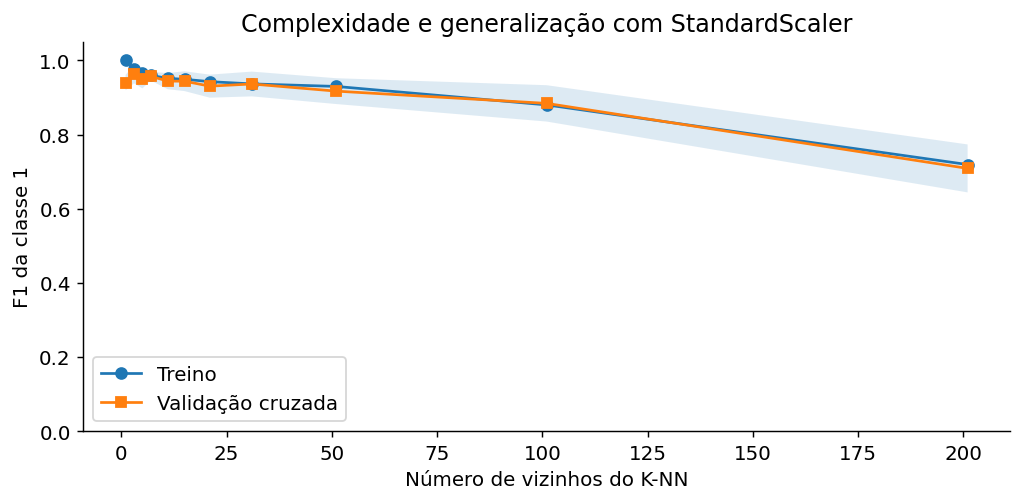

In [ ]:
curva_classificacao = tabela_cv[tabela_cv['escala'] == 'StandardScaler'].sort_values('k')
plt.plot(curva_classificacao['k'], curva_classificacao['F1_treino'], 'o-', label='Treino')
plt.plot(curva_classificacao['k'], curva_classificacao['F1_validacao'], 's-', label='Validação cruzada')
plt.fill_between(curva_classificacao['k'],
                 curva_classificacao['F1_validacao'] - curva_classificacao['desvio_folds'],
                 curva_classificacao['F1_validacao'] + curva_classificacao['desvio_folds'], alpha=.15)
plt.xlabel('Número de vizinhos do K-NN'); plt.ylabel('F1 da classe 1')
plt.title('Complexidade e generalização com StandardScaler')
plt.ylim(0, 1.05); plt.legend(); plt.tight_layout(); plt.show()


**Pergunta 3.** Compare `k=1`, `k=21` e `k=201`. Use valores de treino e validação para discutir flexibilidade e subajuste. Não conclua sobreajuste apenas porque há uma pequena diferença entre duas notas.

Resposta da dupla: ...

## 7 Avaliação final
A busca terminou. Agora calcularemos as métricas do modelo selecionado e da regra majoritária.
A regra de referência, ou **baseline**, sempre prevê a classe mais frequente do desenvolvimento. Ela não usa os atributos.
Depois de observar o teste, registre o resultado; não mude `k`, escala ou semente para melhorar essa nota.
`zero_division=0` registra zero quando a precisão/F1 não pode ser calculada por ausência de previsões positivas; isso deve ser explicado no relatório.


VN=71, FP=1, FN=4, VP=38
              precision    recall  f1-score   support

 benigno (0)      0.947     0.986     0.966        72
 maligno (1)      0.974     0.905     0.938        42

    accuracy                          0.956       114
   macro avg      0.961     0.945     0.952       114
weighted avg      0.957     0.956     0.956       114



,modelo,acuracia,precisao_1,recall_1,F1_1
0,Classe majoritária,0.6316,0.0000,0.0000,0.0000
1,K-NN selecionado,0.9561,0.9744,0.9048,0.9383


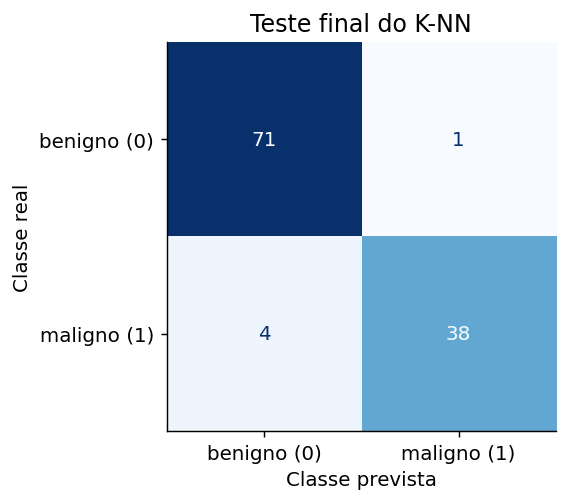

In [ ]:
# Modelo e métrica principal definidos antes desta célula.
modelo_final = busca.best_estimator_  # já reajustado sobre todos os dados de desenvolvimento
pred_teste = modelo_final.predict(X_teste)
baseline = DummyClassifier(strategy='most_frequent').fit(X_dev, y_dev)
pred_base = baseline.predict(X_teste)

def metricas_clf(nome, real, previsto):
    return {'modelo': nome, 'acuracia': accuracy_score(real, previsto),
            'precisao_1': precision_score(real, previsto, zero_division=0),
            'recall_1': recall_score(real, previsto, zero_division=0),
            'F1_1': f1_score(real, previsto, zero_division=0)}

tabela_teste = pd.DataFrame([
    metricas_clf('Classe majoritária', y_teste, pred_base),
    metricas_clf('K-NN selecionado', y_teste, pred_teste)])
display(tabela_teste.round(4))
cm = confusion_matrix(y_teste, pred_teste, labels=[0, 1])
vn, fp, fn, vp = cm.ravel()
print(f'VN={vn}, FP={fp}, FN={fn}, VP={vp}')
print(classification_report(y_teste, pred_teste, labels=[0, 1],
      target_names=['benigno (0)', 'maligno (1)'], digits=3, zero_division=0))
ConfusionMatrixDisplay(cm, display_labels=['benigno (0)', 'maligno (1)']).plot(cmap='Blues', colorbar=False)
plt.xlabel('Classe prevista'); plt.ylabel('Classe real')
plt.title('Teste final do K-NN'); plt.tight_layout(); plt.show()


**Pergunta 4.** Quantas amostras da classe positiva foram previstas como negativas? A qual célula da matriz e a qual tipo de erro correspondem?

Resposta da dupla: ...

**Pergunta 5.** Compare o K-NN com a regra majoritária. Acurácia isolada seria suficiente? Cite pelo menos dois números.

Resposta da dupla: ...

**Leitura do relatório.** `support` é a quantidade de exemplos reais de cada classe. `macro avg` dá o mesmo peso a cada classe; `weighted avg` pondera pelo support. O F1 da classe 1 é a métrica escolhida nesta prática, não a média ponderada.

## 8 Registro de conclusão
Complete: “Selecionamos escala ___ e k ___ usando ___. No teste, o F1 foi ___, com ___ falsos negativos e ___ falsos positivos. Esse resultado estima o desempenho em dados semelhantes, mas não garante o resultado em outra população.”

## Fontes
- [scikit-learn — base Breast Cancer Wisconsin](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html).
- [Pipeline e prevenção de vazamento](https://scikit-learn.org/stable/common_pitfalls.html).
- [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [Matriz de confusão](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html) e [relatório de classificação](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html).
Código e atividades preparados para esta aula. Referência de conteúdo: IBM/Skills Network, Evaluating Classification Models, notebook anexado, autoria indicada de Jeff Grossman, 2024.
